# Problem Set III - Question 1

**Course:** QPROG - Quantum Programming

**Students:** Jady Pâmella Barbacena da Silva and Navyashree Suryanarayana Rao Prasanna

**Group:** Group ProblemSet-III-N  

**Assignment:** Implementing the Quantum Fourier Transform in Qiskit

## Task 1.1: Preparation

Install required packages.

In [135]:
%pip install qiskit==2.2.3
%pip install qiskit-aer==0.17.2
%pip install matplotlib
%pip install numpy
%pip install pylatexenc





Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\jadyp\appdata\local\programs\python\python312\lib\site-packages (3.9.2)

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\jadyp\appdata\local\programs\python\python312\lib\site-packages (3.9.2)







In [136]:
# Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

## Task 1.2: QFT acting on the first n qbits

Implement the Quantum Fourier Transform acting on the first n qubits.

In [137]:
def apply_qft(n, circuit):
    """
    Apply QFT on the first n qubits of the circuit.
    """
    
    # Initial barrier
    circuit.barrier()

    # For each qubit j from n-1 down to 0
    for j in range(n-1, -1, -1):
        # Apply Hadamard gate on qubit j
        circuit.h(j)
        
        # Apply controlled phase gates
        for k in range(j-1, -1, -1):
            # Phase shift: π/2^(j-k)
            circuit.cp(np.pi / 2**(j-k), k, j)
        
        # Barrier after each qubit's operations
        circuit.barrier()
    
    # Swap qubits to reverse the order
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)
    
    return circuit

## Task 1.3: Inverse QFT

Implement the Inverse Quantum Fourier Transform by reversing gates and negating phases.

In [138]:
def apply_iqft(n, circuit):
    """
    Apply Inverse QFT on the first n qubits of the circuit.
    """
    
    # First, swap qubits (reverse of the final step in QFT)
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)
    
    circuit.barrier()
    
    # Apply inverse rotations in reverse order
    for j in range(n):
        # Apply inverse controlled phase gates FIRST (in reverse order with negative angles)
        for k in range(j):
            # Negative phase shift: -π/2^(j-k)
            circuit.cp(-np.pi / 2**(j-k), k, j)
        
        # Apply Hadamard gate after (self-inverse)
        circuit.h(j)
        
        # Barrier after each qubit's operations
        circuit.barrier()
    
    return circuit

## Task 1.4: Generalizing the QFT Functions

Generalize QFT and Inverse QFT to work on arbitrary lists of qubits.

In [139]:
def apply_qft_gen(qubits, circuit):
    """
    Apply QFT on the qubits specified in the list.
    """

    n = len(qubits)

    # Initial barrier
    circuit.barrier()
    
    # For each qubit j from n-1 down to 0
    for j in range(n-1, -1, -1):
        # Apply Hadamard gate on qubits[j]
        circuit.h(qubits[j])
        
        # Apply controlled phase gates
        for k in range(j-1, -1, -1):
            # Phase shift: π/2^(j-k)
            circuit.cp(np.pi / 2**(j-k), qubits[k], qubits[j])
        
        # Barrier after each qubit's operations
        circuit.barrier()
    
    # Swap qubits to reverse the order
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - i - 1])
    
    return circuit


def apply_iqft_gen(qubits, circuit):
    """
    Apply Inverse QFT on the qubits specified in the list.
    """
    
    n = len(qubits)
    
    # First, swap qubits
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - i - 1])
    
    circuit.barrier()
    
    # Apply inverse rotations in reverse order
    for j in range(n):
        # Apply inverse controlled phase gates FIRST
        for k in range(j):
            # Negative phase shift: -π/2^(j-k)
            circuit.cp(-np.pi / 2**(j-k), qubits[k], qubits[j])
        
        # Apply Hadamard gate AFTER
        circuit.h(qubits[j])
        
        # Barrier after each qubit's operations
        circuit.barrier()
    
    return circuit

## Test Task 1.2: QFT acting on the first n qbits

Test the apply_qft function as specified in the assignment III (Figure 1 and Figure 2).

Task 1.2 - QFT on 3 qubits:
      ░                         ░                ░ ┌───┐ ░    
q_0: ─░────────────────■────────░───────■────────░─┤ H ├─░──X─
      ░                │        ░ ┌───┐ │P(π/2)  ░ └───┘ ░  │ 
q_1: ─░───────■────────┼────────░─┤ H ├─■────────░───────░──┼─
      ░ ┌───┐ │P(π/2)  │P(π/4)  ░ └───┘          ░       ░  │ 
q_2: ─░─┤ H ├─■────────■────────░────────────────░───────░──X─
      ░ └───┘                   ░                ░       ░    



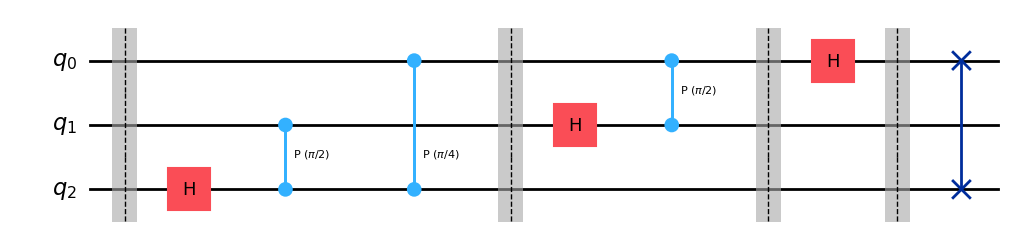

In [140]:
n = 3
circuit = QuantumCircuit(n, 0)
apply_qft(n, circuit)
print("Task 1.2 - QFT on 3 qubits:")
print(circuit)
print()
circuit.draw('mpl')

Task 1.2 - QFT on 4 qubits:
      ░                                  ░                         ░      »
q_0: ─░─────────────────────────■────────░────────────────■────────░──────»
      ░                         │        ░                │        ░ ┌───┐»
q_1: ─░────────────────■────────┼────────░───────■────────┼────────░─┤ H ├»
      ░                │        │        ░ ┌───┐ │P(π/2)  │P(π/4)  ░ └───┘»
q_2: ─░───────■────────┼────────┼────────░─┤ H ├─■────────■────────░──────»
      ░ ┌───┐ │P(π/2)  │P(π/4)  │P(π/8)  ░ └───┘                   ░      »
q_3: ─░─┤ H ├─■────────■────────■────────░─────────────────────────░──────»
      ░ └───┘                            ░                         ░      »
«               ░ ┌───┐ ░       
«q_0: ─■────────░─┤ H ├─░──X────
«      │P(π/2)  ░ └───┘ ░  │    
«q_1: ─■────────░───────░──┼──X─
«               ░       ░  │  │ 
«q_2: ──────────░───────░──┼──X─
«               ░       ░  │    
«q_3: ──────────░───────░──X────
«               ░       

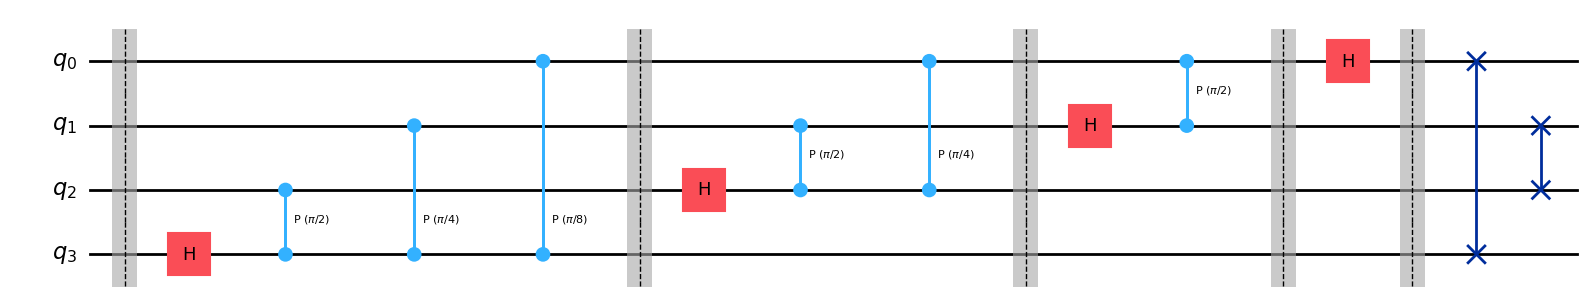

In [141]:
# Test with n=4 (Figure 2)
n = 4
circuit = QuantumCircuit(n, 0)
apply_qft(n, circuit)
print("Task 1.2 - QFT on 4 qubits:")
print(circuit)
print()
circuit.draw('mpl')

## Test Task 1.3: Inverse QFT

Test apply_iqft with n=4 (Figure 3).

Task 1.3 - Inverse QFT on 4 qubits:
            ░ ┌───┐ ░                 ░                           ░           »
q_0: ─X─────░─┤ H ├─░──■──────────────░──■────────────────────────░──■────────»
      │     ░ └───┘ ░  │P(-π/2) ┌───┐ ░  │                        ░  │        »
q_1: ─┼──X──░───────░──■────────┤ H ├─░──┼─────────■──────────────░──┼────────»
      │  │  ░       ░           └───┘ ░  │P(-π/4)  │P(-π/2) ┌───┐ ░  │        »
q_2: ─┼──X──░───────░─────────────────░──■─────────■────────┤ H ├─░──┼────────»
      │     ░       ░                 ░                     └───┘ ░  │P(-π/8) »
q_3: ─X─────░───────░─────────────────░───────────────────────────░──■────────»
            ░       ░                 ░                           ░           »
«                               ░ 
«q_0: ──────────────────────────░─
«                               ░ 
«q_1: ─■────────────────────────░─
«      │                        ░ 
«q_2: ─┼─────────■──────────────░─
«      │P(-π/4)  │P(-π/2) ┌───┐ ░ 

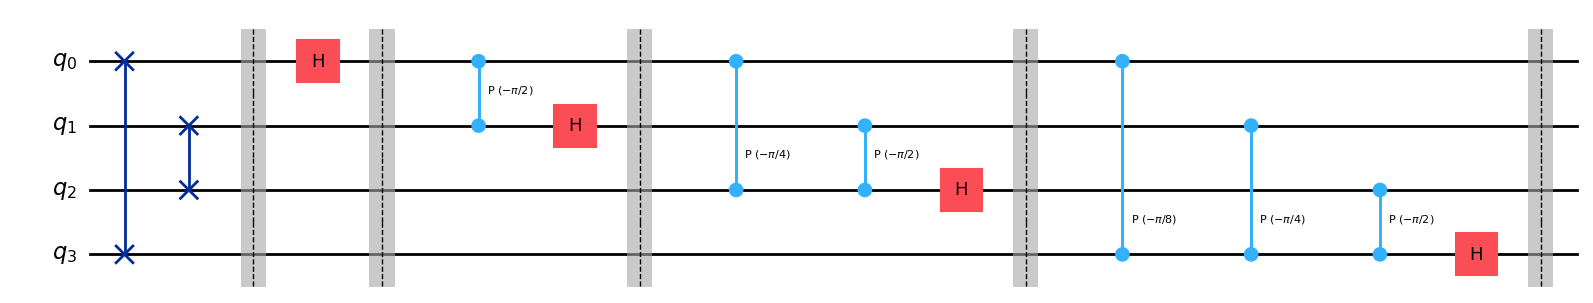

In [142]:
n = 4
circuit = QuantumCircuit(n, 0)
apply_iqft(n, circuit)
print("Task 1.3 - Inverse QFT on 4 qubits:")
print(circuit)
print()
circuit.draw('mpl')

## Test Task 1.4: Generalized QFT

Test apply_qft_gen and apply_iqft_gen on arbitrary qubit lists.

Task 1.4 - Generalized QFT on qubits [0, 2, 4]:
      ░                         ░                ░ ┌───┐ ░    
q_0: ─░────────────────■────────░───────■────────░─┤ H ├─░──X─
      ░                │        ░       │        ░ └───┘ ░  │ 
q_1: ─░────────────────┼────────░───────┼────────░───────░──┼─
      ░                │        ░ ┌───┐ │P(π/2)  ░       ░  │ 
q_2: ─░───────■────────┼────────░─┤ H ├─■────────░───────░──┼─
      ░       │        │        ░ └───┘          ░       ░  │ 
q_3: ─░───────┼────────┼────────░────────────────░───────░──┼─
      ░ ┌───┐ │P(π/2)  │P(π/4)  ░                ░       ░  │ 
q_4: ─░─┤ H ├─■────────■────────░────────────────░───────░──X─
      ░ └───┘                   ░                ░       ░    



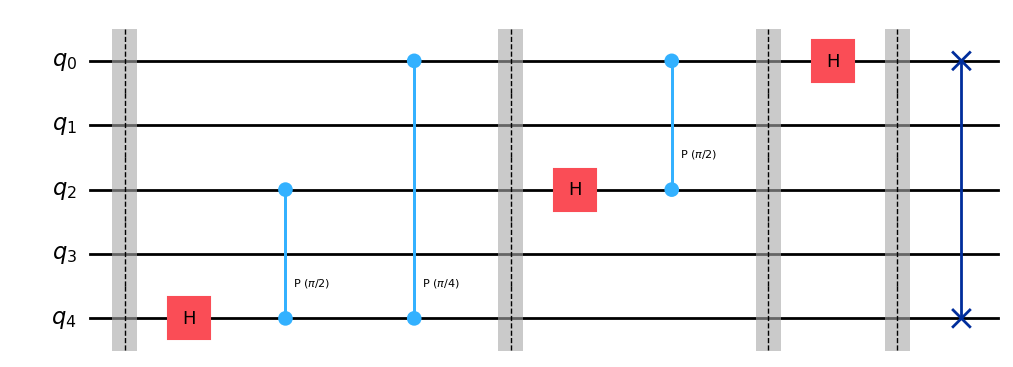

In [143]:
# Test generalized QFT
circuit = QuantumCircuit(5, 0)
qubits = [0, 2, 4]
apply_qft_gen(qubits, circuit)
print(f"Task 1.4 - Generalized QFT on qubits {qubits}:")
print(circuit)
print()
circuit.draw('mpl')

Task 1.4 - Generalized Inverse QFT on qubits [0, 2, 4]:
         ░ ┌───┐ ░                 ░                           ░ 
q_0: ─X──░─┤ H ├─░──■──────────────░──■────────────────────────░─
      │  ░ └───┘ ░  │              ░  │                        ░ 
q_1: ─┼──░───────░──┼──────────────░──┼────────────────────────░─
      │  ░       ░  │P(-π/2) ┌───┐ ░  │                        ░ 
q_2: ─┼──░───────░──■────────┤ H ├─░──┼─────────■──────────────░─
      │  ░       ░           └───┘ ░  │         │              ░ 
q_3: ─┼──░───────░─────────────────░──┼─────────┼──────────────░─
      │  ░       ░                 ░  │P(-π/4)  │P(-π/2) ┌───┐ ░ 
q_4: ─X──░───────░─────────────────░──■─────────■────────┤ H ├─░─
         ░       ░                 ░                     └───┘ ░ 



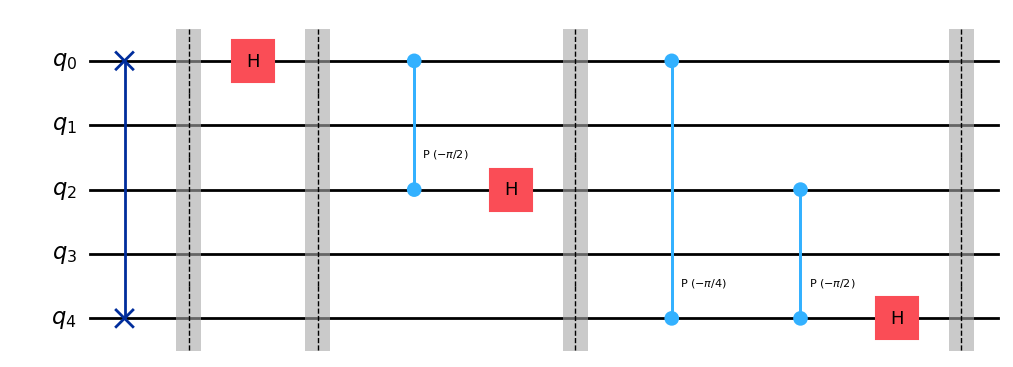

In [144]:
# Test generalized Inverse QFT
circuit = QuantumCircuit(5, 0)
qubits = [0, 2, 4]
apply_iqft_gen(qubits, circuit)
print(f"Task 1.4 - Generalized Inverse QFT on qubits {qubits}:")
print(circuit)
print()
circuit.draw('mpl')